<p align="center">
  <a href="https://vicena.ai"><strong>Built with Vicena</strong></a>
</p>

# Quickstart: batch, CSTR, and PFR

This notebook is part of the Vicena Research Twins collection.

## Purpose and scientific status
Execute the synthetic Level 0 reactor reference. Numerical convergence is not chemical validity.

## Inputs and units
Concentration: mol/m3. Time: s. Temperature: K. Pressure: Pa. Heat transfer: W/K or W/(m3 K).

## Execution and printed results
The cells print conversions, temperatures, and solver diagnostics, then plot concentrations.

## Validation and limitations
Use the dedicated validation notebook and RUNS.md. Ideal mixing, phase behavior, mass transfer, scale-up, and thermal hazards are outside this baseline.

In [9]:
import sys
from pathlib import Path
root = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.insert(0, str(root/'src'))
import numpy as np
import matplotlib.pyplot as plt
from chemical_reactor_twin import ReactionNetwork, simulate_batch, simulate_cstr, simulate_pfr

In [10]:
net = ReactionNetwork(['A','B','C'], [[-1,1,0],[-1,0,1]], [20,2], [12000,15000], [[1,0,0],[1,0,0]], [-20000,-30000])
feed = np.array([1000.,0.,0.])
b = simulate_batch(net, feed, 330, 10, volume=0.001, ua=25, coolant_temperature=330)
c = simulate_cstr(net, feed, 330, 10, ua_over_volume=25000, coolant_temperature=330)
p = simulate_pfr(net, feed, 330, 10, ua_over_volume=25000, coolant_temperature=330)
for name, r in [('batch',b),('CSTR',c),('PFR',p)]:
    print(name, 'conversion', 1-r.concentration[-1,0]/1000, 'T_K', r.temperature[-1], r.diagnostics)

batch conversion 0.9337973722557376 T_K 334.35561551474194 {'success': True, 'message': 'The solver successfully reached the end of the integration interval.', 'nfev': 116, 'njev': 1, 'method': 'BDF', 'rtol': 1e-07, 'atol': 1e-09, 'min_concentration': 0.0, 'max_temperature_K': 334.35561551474194}
CSTR conversion 0.7314773609333742 T_K 333.356488370749 {'success': True, 'message': '`gtol` termination condition is satisfied.', 'nfev': 24, 'residual_norm': 6.007698035412917e-11, 'solver': 'least_squares', 'max_temperature_K': 333.356488370749}
PFR conversion 0.9337973722557875 T_K 334.35561551474245 {'success': True, 'message': 'The solver successfully reached the end of the integration interval.', 'nfev': 116, 'njev': 1, 'method': 'BDF', 'rtol': 1e-07, 'atol': 1e-09, 'max_temperature_K': 334.35561551474245}


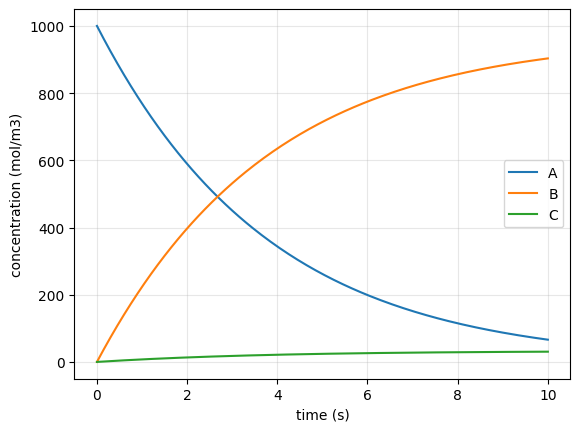

In [11]:
plt.plot(b.coordinate, b.concentration)
plt.xlabel('time (s)'); plt.ylabel('concentration (mol/m3)'); plt.legend(net.species); plt.grid(alpha=.3); plt.show()